In [1]:
import numpy as np
import h5py
import corner
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, auc


import matplotlib.pyplot as plt
from astroML.utils import completeness_contamination

In [2]:
data = h5py.File('sample_2e7_design_precessing_higherordermodes_3detectors.h5', 'r')

In [3]:
data.keys()

<KeysViewHDF5 ['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'det', 'iota', 'mtot', 'psi', 'q', 'ra', 'snr', 'z']>

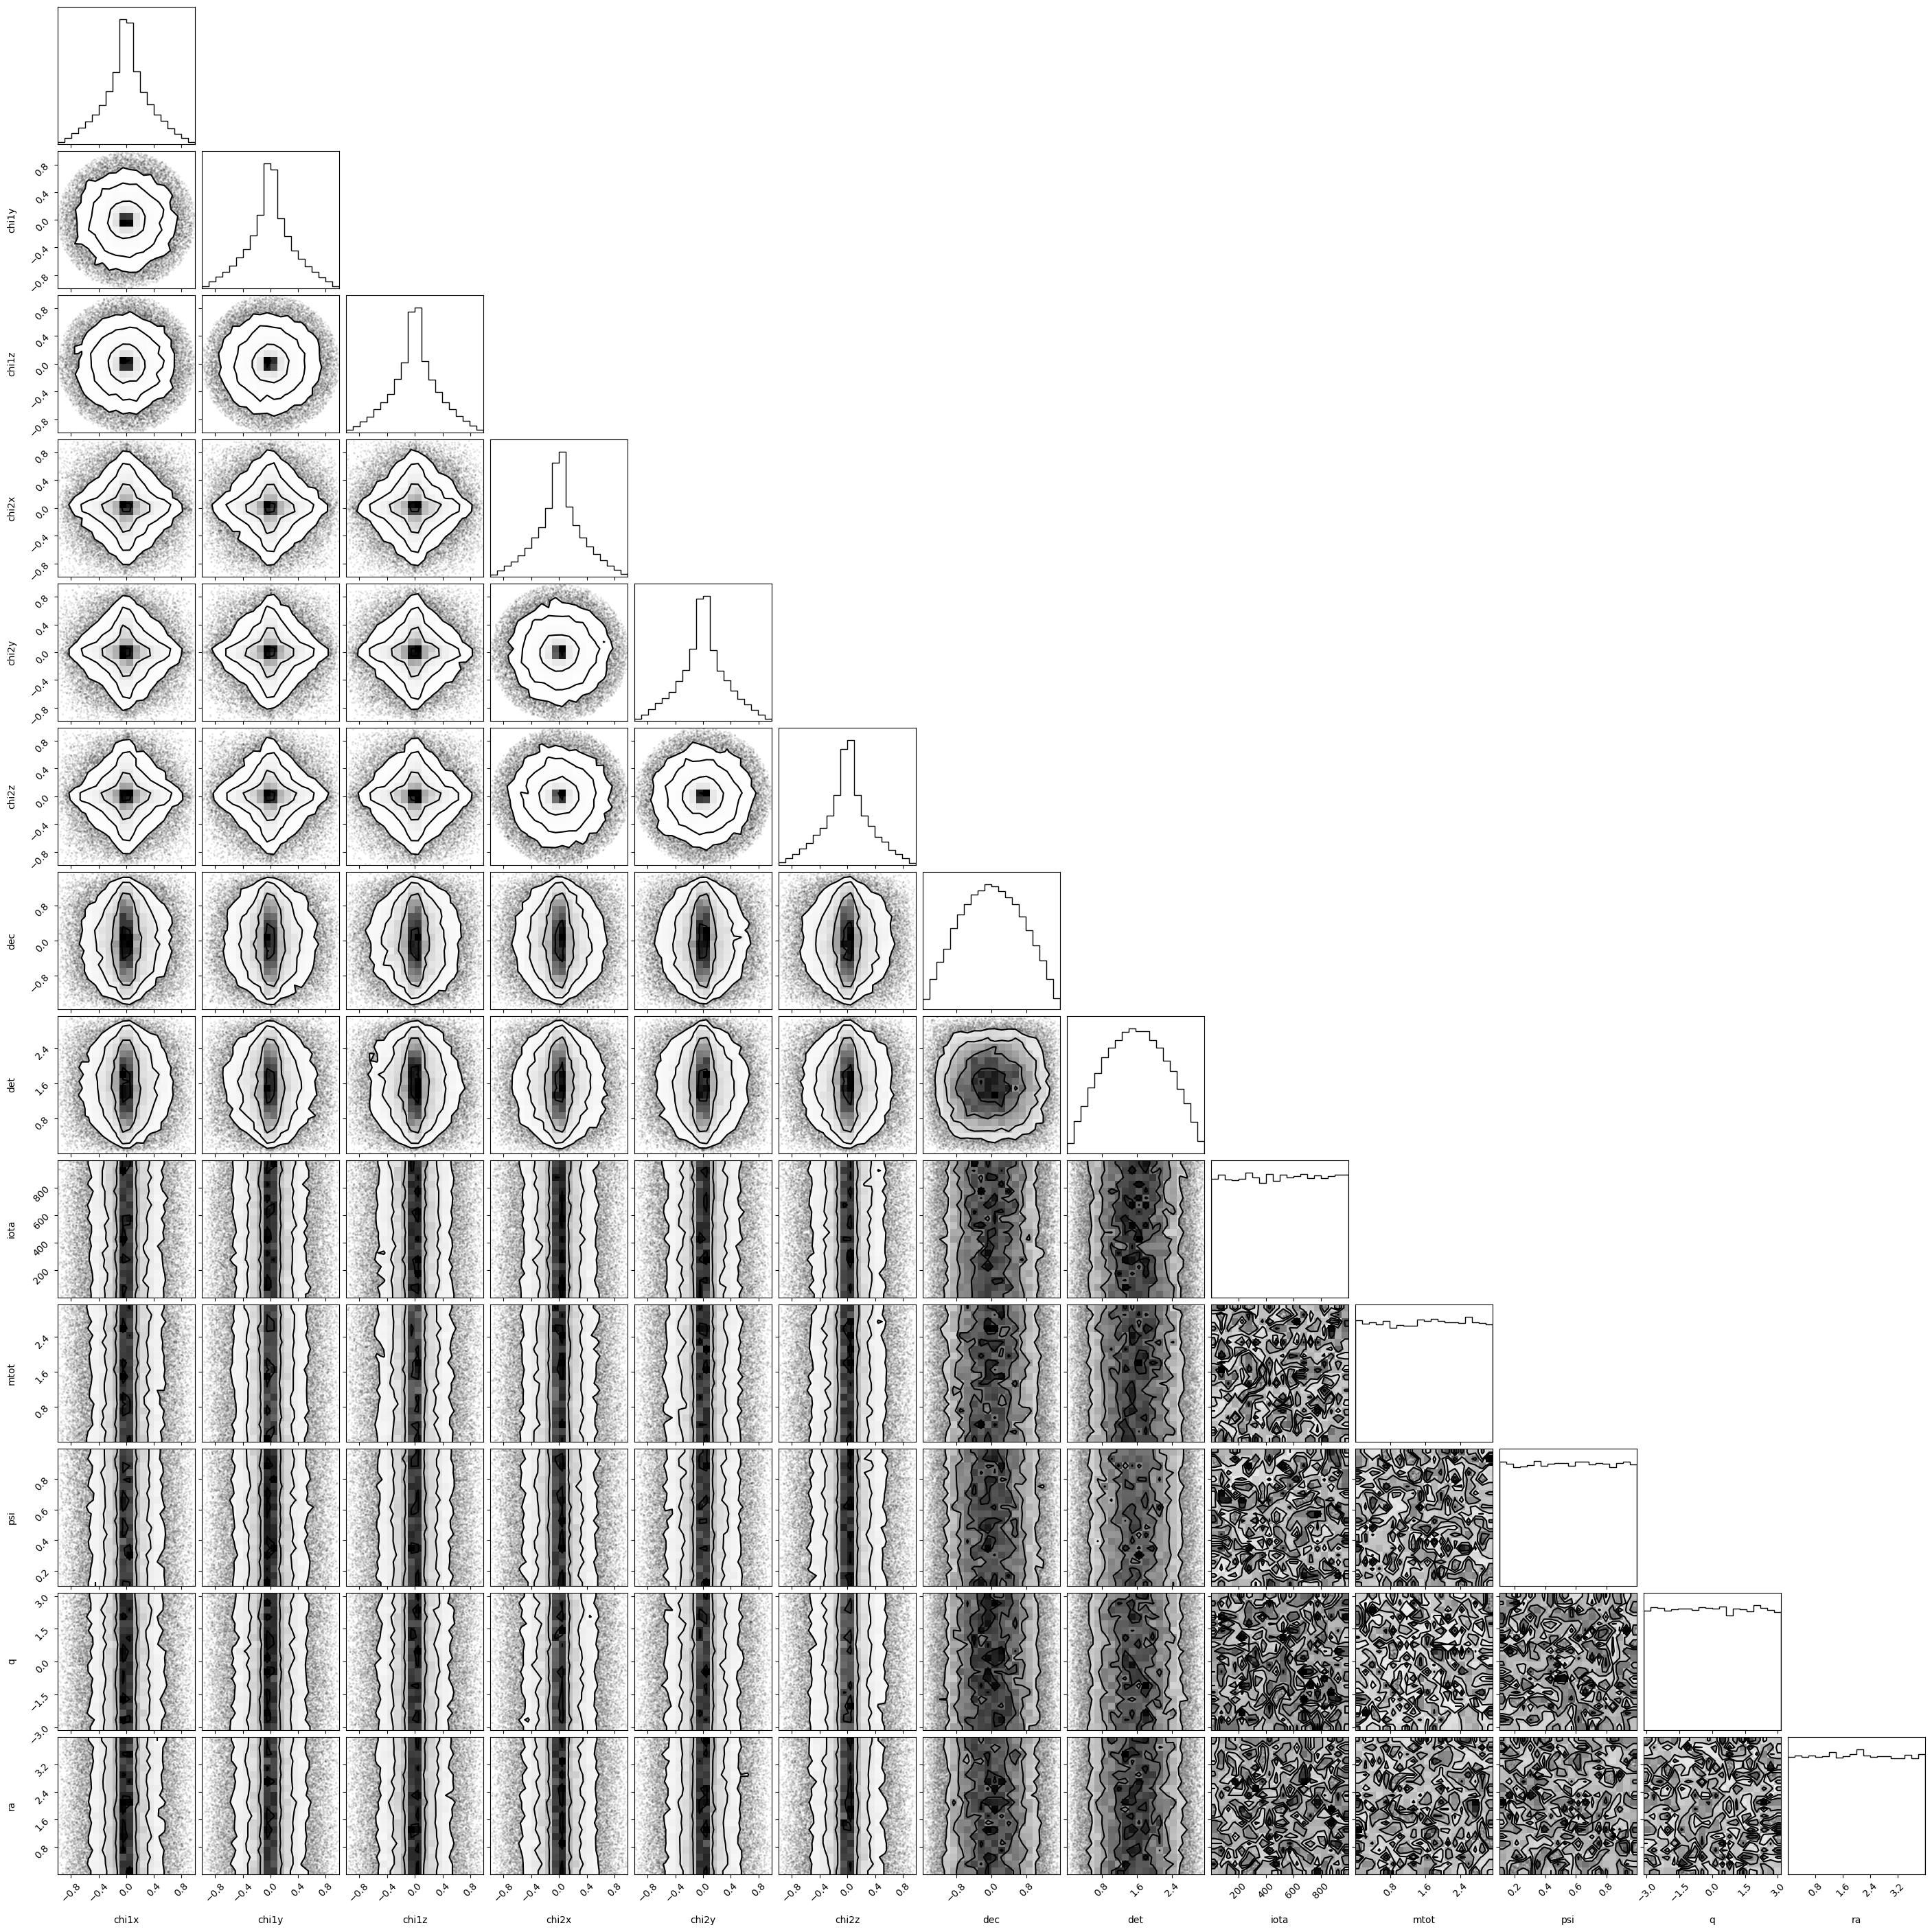

In [4]:
s = 50000 #number data i take into consideration for first analyses

corner_matrix = np.column_stack([
    data['chi1x'][:s],
    data['chi1y'][:s],
    data['chi1z'][:s],
    data['chi2x'][:s],
    data['chi2y'][:s],
    data['chi2z'][:s],
    data['dec'][:s],
    # data['det'][:s],
    data['iota'][:s],
    data['mtot'][:s],
    data['psi'][:s],
    data['q'][:s],
    data['ra'][:s],
    data['z'][:s]
])


figure = corner.corner(corner_matrix, labels=['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'det', 'iota', 'mtot', 'psi', 'q', 'ra', 'snr', 'z'])

In [5]:
snr =  data['snr'][:s]
snr_label = (data['snr'][:s] > 12).astype(bool)
scaler = StandardScaler()
prova_t = scaler.fit_transform(corner_matrix)

I didn't undestand 'det' was already what I was searching...

In [6]:
prova_train, prova_test, snr_train, snr_test = train_test_split(prova_t, snr_label, test_size = 0.2)


bag_clf = BaggingClassifier(
    DecisionTreeClassifier(random_state=42), 
    n_estimators=500, max_samples=1000, #n_estimators set the number of different trees, max_samples set the number of data each tree looks into
    bootstrap=True, random_state=42, n_jobs=-1)

print(snr_train)
bag_clf.fit(prova_train, snr_train)
snr_pred = bag_clf.predict(prova_test)



[ True  True False ... False False False]


In [7]:

accuracy_score(snr_test, snr_pred)

0.9613

pretty good, now on all set

In [8]:
s = 2000000

corner_matrix = np.column_stack([
    data['chi1x'][:s],
    data['chi1y'][:s],
    data['chi1z'][:s],
    data['chi2x'][:s],
    data['chi2y'][:s],
    data['chi2z'][:s],
    data['dec'][:s],
    # data['det'][:s],
    data['iota'][:s],
    data['mtot'][:s],
    data['psi'][:s],
    data['q'][:s],
    data['ra'][:s],
    data['z'][:s]
])

snr =  data['snr'][:s]
snr_label = (snr > 12).astype(bool)


In [9]:
prova_train, prova_test, snr_train, snr_test = train_test_split(corner_matrix, snr_label, test_size = 0.25)



print(snr_train)
bag_clf.fit(prova_train, snr_train)
snr_pred = bag_clf.predict(prova_test)



[ True  True False ... False False False]


In [10]:
accuracy_score(snr_test, snr_pred)

0.958756

look, not all dataset is really fitted: only 500 trees * 1000 samples ~ 1/4. maybe I should use more trees/samples 

In [11]:

bag_clf = BaggingClassifier(
    DecisionTreeClassifier(random_state=42), 
    n_estimators=1000, max_samples=1000, #n_estimators set the number of different trees, max_samples set the number of data each tree looks into
    bootstrap=True, random_state=42, n_jobs=-1)

# print(snr_train)
bag_clf.fit(prova_train, snr_train)
snr_pred = bag_clf.predict(prova_test)
print(accuracy_score(snr_test, snr_pred))

0.95869


now small kfold to undestand if all features are important

In [12]:
from sklearn.model_selection import KFold

kfold = KFold(shuffle =True)

In [13]:
def scaler (data_train, data_test ):
    scal = StandardScaler()
    scaled_train = scal.fit_transform(data_train)
    scaled_test = scal.transform(data_test)
    return scaled_train, scaled_test


1-feature score 0.8556595 +- 0.00047951902986220193
2-feature score 0.8556595 +- 0.00033742184280216684
3-feature score 0.8556595 +- 0.0006870323864273058
4-feature score 0.8556595 +- 0.00023792540847921987
5-feature score 0.8556595000000001 +- 0.000494445143570034
6-feature score 0.8556595 +- 0.00036484380219485243
7-feature score 0.8556595 +- 0.00040926275178666956
8-feature score 0.8556595 +- 0.0003519353633837091
9-feature score 0.8556595 +- 0.0004507449389621363
10-feature score 0.8556595 +- 0.000354645597745137
11-feature score 0.8556595 +- 0.0004189999999999903
12-feature score 0.8556595 +- 0.0005243267111258168
13-feature score 0.9673959999999999 +- 0.0004340524161895703


Text(0.5, 0, 'false positive rate')

/home/matti/uni/lab/myenv/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/matti/uni/lab/myenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


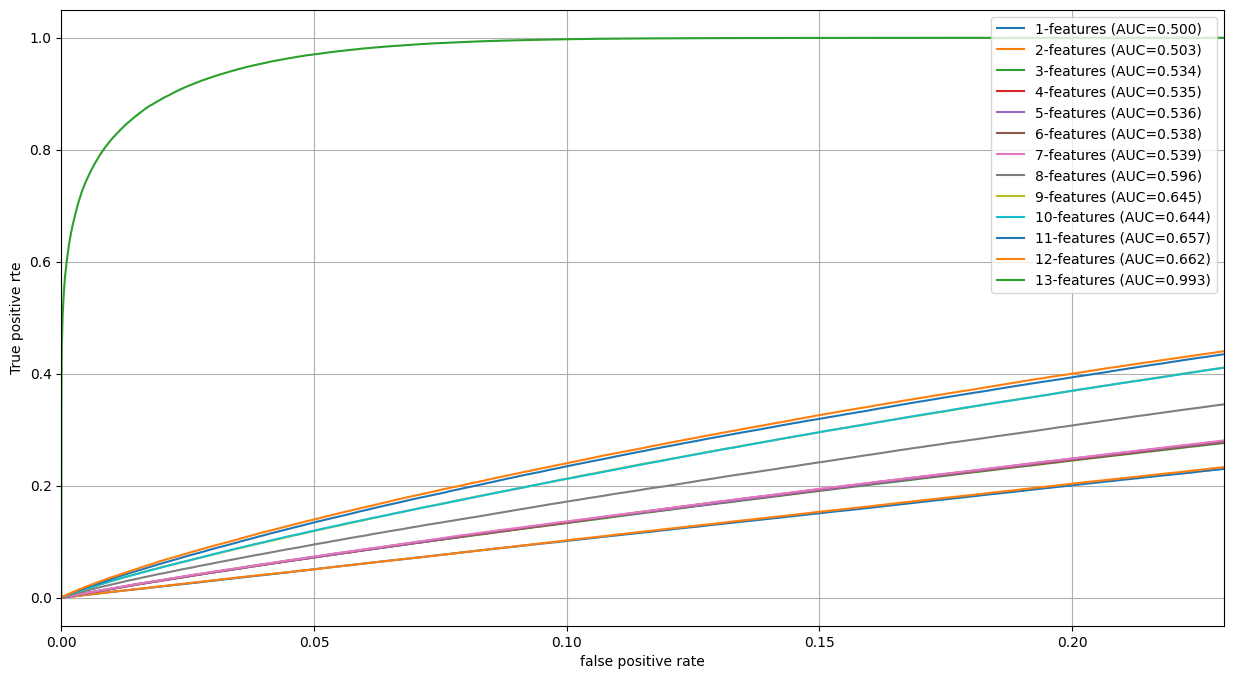

In [15]:
features_list = [
    'chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 
    'dec', 'iota', 'mtot', 'psi', 'q', 'ra', 'z']


base_tree = DecisionTreeClassifier(criterion= 'entropy',
    # max_depth=6,
    min_samples_split=30,
    min_samples_leaf=15,
)

bag_clf = BaggingClassifier(
    base_tree, 
    n_estimators=500, max_samples=50000, #n_estimators set the number of different trees, max_samples set the number of data each tree looks into
    bootstrap=True,  n_jobs=-1)


s = 2000000
# s = 10000
plt.figure(figsize= (15, 8))

corner_matrix = np.column_stack([
    data['chi1x'][:s],
    data['chi1y'][:s],
    data['chi1z'][:s],
    data['chi2x'][:s],
    data['chi2y'][:s],
    data['chi2z'][:s],
    data['dec'][:s],
    data['iota'][:s],
    data['mtot'][:s],
    data['psi'][:s],
    data['q'][:s],
    data['ra'][:s],
    data['z'][:s]
])

snr =  data['snr'][:s]
snr_label = (snr > 12).astype(bool)

completeness_values = []
contamination_values = []

for i in range (len(features_list)):
    keys = features_list[:i+1]
    matrix = np.column_stack([data[f'{key}'][:s] for key in keys])
    fold_mse = []
    fold_fpr_list = []
    fold_tpr_list = []
    fold_comp = []
    fold_cont = []
    all_preds_proba = []
    all_true_labels = []
    scores = []
    
    for (train_index, test_index ) in kfold.split(matrix):
        data_train, data_cv_test = matrix[train_index], matrix[test_index]
        snr_cv_train, snr_cv_test = snr_label[train_index], snr_label[test_index]
        d_train, d_cv_test = scaler(data_train, data_cv_test)

        bag_clf.fit(d_train, snr_cv_train)
        snr_pred = bag_clf.predict(d_cv_test)
        snr_pred_proba = bag_clf.predict_proba(d_cv_test)
        
        scores.append(accuracy_score(snr_cv_test, snr_pred))

        comp, cont = completeness_contamination( snr_pred, snr_cv_test)
        
        fold_comp.append(comp)
        fold_cont.append(cont)
        all_preds_proba.append(snr_pred_proba[:, 1])
        all_true_labels.append(snr_cv_test)
        scores.append(accuracy_score(snr_cv_test, snr_pred))
    
    # Calculate SINGLE ROC curve from all fold predictions
    all_preds_proba = np.concatenate(all_preds_proba)
    all_true_labels = np.concatenate(all_true_labels)

    
    completeness_values.append(np.mean(fold_comp))
    contamination_values.append(np.mean(fold_cont))
    
    fpr, tpr, _ = roc_curve(all_true_labels, all_preds_proba)
    auc_score = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f'{i+1}-features (AUC={auc_score:.3f})')
    print(f'{i+1}-feature score', np.mean(scores), '+-', np.std(scores))

plt.grid()
plt.xlim((0, 0.23))
plt.legend()
plt.ylabel('True positive rte')
plt.xlabel('false positive rate')

Text(0, 0.5, 'contamination')

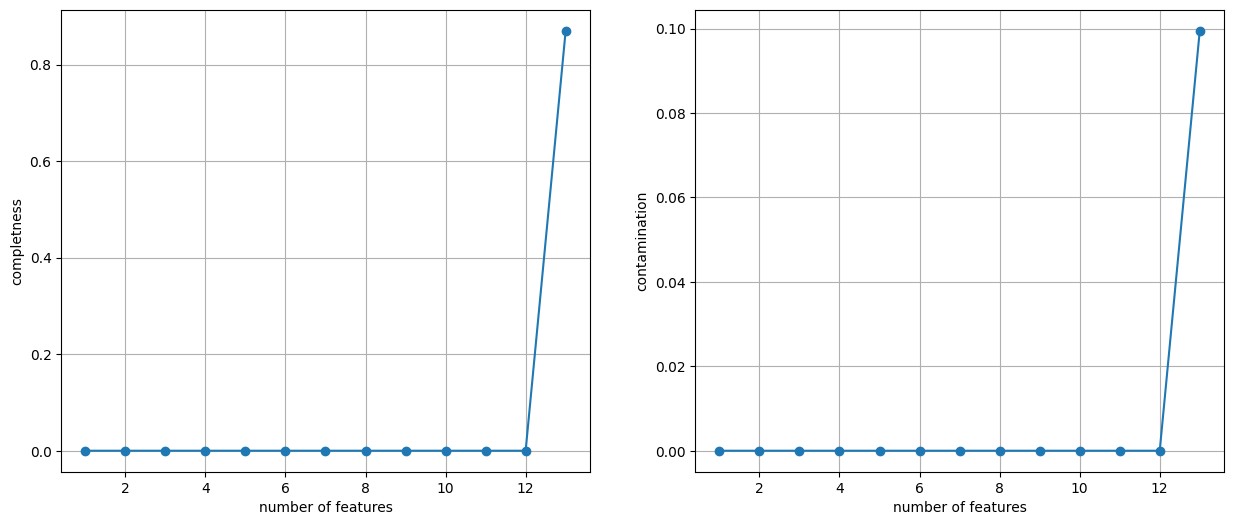

In [16]:
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 6))
ax1.plot(np.linspace(1, 13, 13), completeness_values, marker = 'o')
ax1.grid()
ax1.set_xlabel('number of features')
ax1.set_ylabel('completness')
ax2.plot(np.linspace(1, 13, 13), contamination_values, marker = 'o')
ax2.grid()
ax2.set_xlabel('number of features')
ax2.set_ylabel('contamination')

1. The Machine Learning Reason: Imbalanced "Safe" GuessesIn your for loop, you are passing hard predictions (snr_pred which are discrete True or False values) into the completeness_contamination function.Gravitational wave events with an SNR > 12 are usually rare compared to the total population of simulated events. If a dataset is heavily imbalanced (e.g., 95% of events are False / quiet), a decision tree model can easily achieve 95% Accuracy by simply guessing False for every single event.If the model predicts False for everything:True Positives = 0 (It caught none of the loud events).False Positives = 0 (It raised no false alarms).Because of this:Completeness = $\frac{TP}{TP + FN} = \frac{0}{0 + FN} =$ 0.0Contamination = $\frac{FP}{TP + FP} = \frac{0}{0} \rightarrow$ defaults to 0.02. The Astrophysics Reason: Weak vs. Strong FeaturesLook at the order of the features in your loop:Pythonfeatures_list = ['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'iota', 'mtot', 'psi', 'q', 'ra', 'z']
Your loop starts by testing just 1 feature, then 2, then 3...At i = 0 to 5 (The Spins): You are asking the model to predict if SNR > 12 based solely on chi1 and chi2 (black hole spins). In physics, spin has a very minor effect on the overall loudness (SNR) of a signal. Because the model cannot find a pattern, it gives up and predicts False for everything. Completeness = 0.At i = 6 to 7 (dec, iota): Sky position and inclination help a little, but not enough to confidently trigger a True prediction. Completeness = 0.At i = 8 (mtot - Total Mass): Suddenly, the model is given Total Mass! Mass directly drives the amplitude of a gravitational wave. The model can finally start identifying loud events confidently. Your completeness will jump up from 0 here!At i = 12 (z - Redshift/Distance): Distance is the ultimate factor for SNR. Once z is included, the model easily identifies the loud events, and Completeness shoots up to its maximum.SummaryYour plots are actually successfully demonstrating Feature Importance.The many 0s at the beginning of your plot show that spins and angles alone are entirely insufficient to predict if an event will have an SNR > 12. The flat 0 lines are mathematically correct because the model is predicting 0 True events until you feed it the powerful features like mtot and z later in the loop.If you want to force the model to try harder on the weak features:Instead of using the default .predict() (which uses a hard 50% probability threshold), you can lower the threshold to force the model to flag events.Python# Instead of this:
# snr_pred = bag_clf.predict(data_cv_test)

# Do this to lower the threshold and force positive predictions:
snr_pred = (bag_clf.predict_proba(data_cv_test)[:, 1] > 0.15) 

comp, cont = completeness_contamination(snr_pred, snr_cv_test)
Lowering the threshold to 15% instead of 50% will force the model to take guesses even with weak features, which will raise your completeness above 0 earlier in the plot (though your contamination will also increase!).